### Networkx

https://networkx.org/documentation/stable/tutorial.html


In [4]:
import math
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

#### Zeichnen von Graphen

##### Gerichtete ungewichtete Graphen

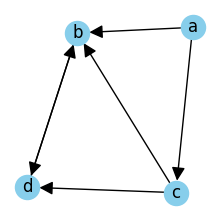

In [51]:
G0 = {
    'a': set('bc'),
    'b': set('d'),
    'c': set('bd'),
    'd': set('b')
}
nodes = list(G0.keys())
edges = [(u,v) for u in G0 for v in G0[u]]
   
G = nx.DiGraph()
G.add_nodes_from(nodes)
G.add_edges_from(edges)      

plt.figure(figsize=(2, 2))
np.random.seed(7)
nx.draw(G, with_labels=True, arrows=True, node_color='skyblue',arrowsize=20)

Man kann das dict auch direct übergeben.

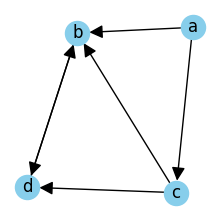

In [41]:
G0 = {
    'a': set('bc'),
    'b': set('d'),
    'c': set('bd'),
    'd': set('b')
}
G = nx.DiGraph(G0)
plt.figure(figsize=(2, 2))
np.random.seed(7)
nx.draw(G, with_labels=True, arrows=True, node_color='skyblue',arrowsize=20)

Die Positionen können wir manuell setzen. Die Positionen müssen nur relativ zueinander stimmen. 

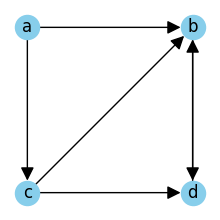

In [42]:
G0 = {
    'a': set('bc'),
    'b': set('d'),
    'c': set('bd'),
    'd': set('b')
}
G = nx.DiGraph(G0)
pos = {'a':(0,1), 'c':(0,0), 'b':(1,1), 'd':(1,0)}
plt.figure(figsize=(2, 2))
nx.draw(G, pos, with_labels=True, arrows=True, node_color='skyblue',arrowsize=20)


##### Ungerichtete ungewichtete Graphen

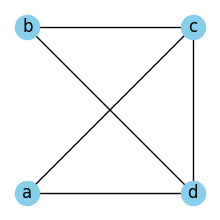

In [53]:
G0 = {
    'a': set('cd'),
    'b': set('cd'),
    'c': set('abd'),
    'd': set('acb')
}
G = nx.Graph(G0)
pos = {'a':(0,0), 'b':(0,1), 'c':(1,1), 'd':(1,0)}
plt.figure(figsize=(2, 2))
nx.draw(G, pos, with_labels=True, node_color='skyblue')

##### Gerichtete gewichtete Graphen

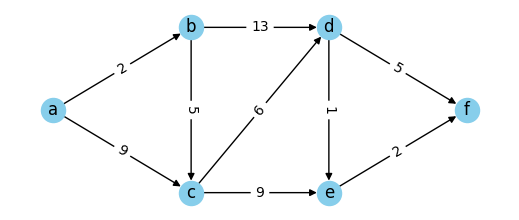

In [54]:
G0 = {
    'a': {'b': 2, 'c': 9},
    'b': {'c': 5, 'd': 13},
    'c': {'d': 6, 'e': 9},
    'd': {'e': 1, 'f': 5},
    'e': {'f': 2},
    'f': {}
}

G = nx.DiGraph()

for u, neighbors in G0.items():
    for v, w in neighbors.items():
        G.add_edge(u, v, weight=w)

#automatisches Layout
#pos = nx.spring_layout(G, seed=5)
#pos = nx.shell_layout(G)

pos = {'a':(0,1), 'b':(1,2), 'c':(1,0), 'd':(2,2), 'e':(2,0), 'f':(3,1)}

plt.figure(figsize=(5, 2))
nx.draw(
    G, pos,
    with_labels=True,
    node_color="skyblue",
    arrows=True
)

edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

plt.show()

##### Ungerichtete gewichtete Graphen

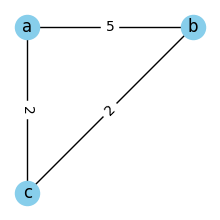

In [57]:
G0 = {
    'a': {'b': 5, 'c': 2},
    'b': {'a': 5, 'c': 2},
    'c': {'a': 2, 'b': 2},
}

G = nx.Graph()

for u, neighbors in G0.items():
    for v, w in neighbors.items():
        G.add_edge(u, v, weight=w)


pos = {'c':(0,0), 'a':(0,1), 'b':(1,1)}

plt.figure(figsize=(2, 2))
nx.draw(
    G, pos,
    with_labels=True,
    node_color="skyblue"
)

edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

plt.show()

##### Bäume

Mit dfs berechnen wir die Breite und Position eines Knotens. Die Breite hängt von der Anzahl der Geschwister ab. 

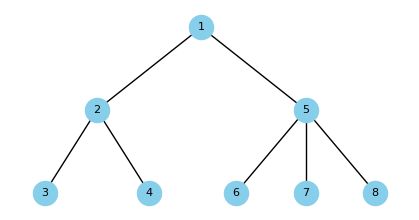

In [19]:
def dfs(u):
    x, y = pos[u]
    for i, v in enumerate(G[u]):
        breite[v] = breite[u]/len(G[u])
        pos[v] = (x-breite[u]/2 +  breite[v]/2 + i*breite[v], y-1)
        dfs(v)

G = {1: [2, 5], 2: [3, 4], 3: [], 4: [], 5: [6, 7, 8], 6: [], 7: [], 8: []}

breite = {1: 1}
pos = {1: (0.5,0)}

dfs(1)
G1 = nx.DiGraph(G)
plt.figure(figsize=(4, 2))
nx.draw(
    G1, pos,
    with_labels=True,
    node_size=300,
    node_color="skyblue",
    arrows=False,
    font_size=8
)
plt.show()


#### Algorithmen auf Graphen

##### Erreichbarkeit

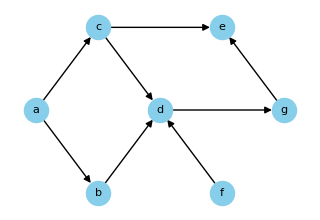

In [65]:
G0 = {'a': set('bc'),
     'b': set('d'),
     'c': set('ed'),
     'd': set('g'),
     'e': set(),
     'f': set('d'),
     'g': set('e')}  

pos = {'a': (0,0),
     'b': (1,-1),
     'c': (1,1),
     'd': (2,0),
     'e': (3,1),
     'f': (3,-1),
     'g': (4,0)}  

plt.figure(figsize=(3, 2))
nx.draw(
    G, pos, 
    with_labels=True,
    node_size=300,
    node_color="skyblue",
    arrows=True,
    font_size=8
)
plt.show()

In [66]:
G = nx.DiGraph(G0)
reachable = nx.descendants(G, 'a')
print(reachable)

{'c', 'e', 'g', 'd', 'b'}


##### bfs

Die Knoten in bfs-Reihenfolge

In [53]:
for u in nx.bfs_tree(G, 'a', sort_neighbors=sorted): 
    print(u)

a
b
c
d
e
g


Die Kanten in bfs-Reihenfolge:

In [67]:
for e in nx.bfs_edges(G, 'a', sort_neighbors=sorted):
    print(e)

('a', 'b')
('a', 'c')
('b', 'd')
('c', 'e')
('d', 'g')


##### dfs

Die Knoten in dfs-Reihenfolge

In [68]:
for u in nx.dfs_tree(G, 'a', sort_neighbors=sorted).nodes:
    print(u)

a
b
d
g
e
c


Die Kanten in dfs-Reihenfolge:

In [69]:
for e in nx.dfs_edges(G, 'a', sort_neighbors=sorted):
    print(e)

('a', 'b')
('b', 'd')
('d', 'g')
('g', 'e')
('a', 'c')
